# 8 — Before a step is taken

Every other notebook here asks whether a network **is** learning, which needs it
to have been learning. This one asks whether it **can**, and it asks before a
single step is taken.

A **probe** is one `forward` that was recorded and never trained. Not a turn of
phrase: it is literally `run/<id>/0`, written through the same `Watcher` a
`Trainer` writes through, so `diagnose`, `profile` and `overlaid` read it
without knowing one exists. It costs a fraction of a second.

What it can say is deliberately narrow. Three numbers are measured and **one**
of them raises an alarm, because the other two were measured too and did not
earn one — and the last section is a family of cheap scores that are not alarms
at all, with the only question worth asking of them.

In [1]:
import math
import time
import tempfile

import torch

import somatize.torch  # noqa: F401
from somatize import Graph, Node, Opaque, Recorder, Store
from somatize.health import about, diagnose, overlaid, profile, seen
from somatize.torch import Trainer, architecture, parameters, probe, proxies

torch.manual_seed(0)
store = Store(tempfile.mkdtemp())

WIDTH, DEPTH, ROWS = 32, 6, 128

## The candidate

A plain stack, six layers deep, with one knob: how big its weights start. `1.0`
is the initialisation everybody ships. The interesting question is what happens
either side of it, and whether anything can be said about that **without
training the thing**.

In [2]:
class Stack(Node):
    """A plain stack, and one knob: how big its weights start."""

    def __init__(self, wide=WIDTH, depth=DEPTH, gain=1.0, norm=False):
        # In and out stay at `WIDTH`, because the task does: what varies is how
        # much room it has in the middle, which is the thing a proxy is being
        # asked to rank.
        made, into = [], WIDTH
        for _ in range(depth):
            made.append(torch.nn.Linear(into, wide))
            if norm:
                made.append(torch.nn.LayerNorm(wide))
            made.append(torch.nn.GELU())
            into = wide
        self.body = torch.nn.Sequential(*made, torch.nn.Linear(into, WIDTH))
        with torch.no_grad():
            for one in self.body.modules():
                if isinstance(one, torch.nn.Linear):
                    # He, times whatever gain is being tried.
                    one.weight.normal_(0, gain * math.sqrt(2 / one.in_features))
                    one.bias.zero_()

    def forward(self, x, ctx):
        return Opaque(self.body(x))

    def parameters(self):
        return list(self.body.parameters())


def built(**how):
    return Graph.somatize(Stack(**how).named("trunk"))


ONE = torch.randn(ROWS, WIDTH)
hot = built(gain=1.6)

## What it looks like

Nothing has run yet in anger — `architecture` traces the node by running the
graph once, and what comes back is what it is made of.

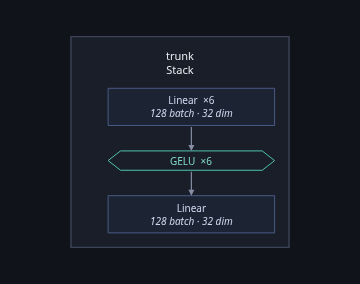

In [3]:
hot.figure(inside=architecture(hot, Opaque(ONE)))

## The probe

One forward, recorded, and no weight moved. The numbers go into the store as
`health` facts under the same keys an audit uses, so the diagnosis is taken the
same way it is taken of a training run — by reading it back.

In [4]:
at = time.time()
probe(hot, ONE, watching=Recorder(store, run="hot"))
cost = time.time() - at

found = diagnose(store, run="hot")
print(f"the probe took {cost:.2f}s")
print(found)

the probe took 0.30s
{'trunk.body.6': ['MISSING_NORMALISATION'], 'trunk.body.8': ['MISSING_NORMALISATION'], 'trunk.body.9': ['MISSING_NORMALISATION'], 'trunk.body.10': ['MISSING_NORMALISATION'], 'trunk.body.11': ['MISSING_NORMALISATION'], 'trunk.body.12': ['MISSING_NORMALISATION']}


It says **where**, and the where is the point: the drift crosses a decade
part-way down the stack, not at the end. And it says what to do about it.

In [5]:
print(about("MISSING_NORMALISATION"))

the signal grows over a stretch with nothing normalising it; the first step will be taken on numbers this size


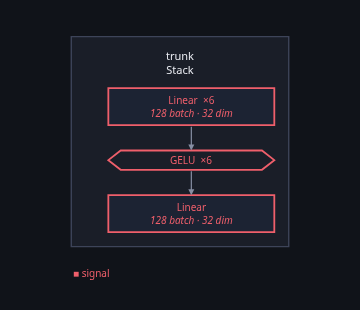

In [6]:
overlaid(hot, store, run="hot", inside=architecture(hot, Opaque(ONE)))

## The same stack, normalised

`MISSING_NORMALISATION` is a **conjunction**, and both halves are load-bearing:
the scale drifted, *and* there was nothing normalising the stretch it drifted
over. The structural half lives inside the measurement — a normalisation resets
the reference and reports no gain of its own, because changing the scale is its
job.

So the same badly-initialised stack, with a `LayerNorm` in each layer, is
measured again. Structure alone would have flagged both of them.

In [7]:
fixed = built(gain=1.6, norm=True)
probe(fixed, ONE, watching=Recorder(store, run="fixed"))

print(diagnose(store, run="fixed") or "nothing tripped")

nothing tripped


## Checking the prediction

The probe is an **opinion**, and an opinion that is never checked is a habit. So
here are the three of them trained for real, against the score of a network that
learnt nothing at all.

In [8]:
torch.manual_seed(1)
teacher = torch.nn.Sequential(
    torch.nn.Linear(WIDTH, WIDTH), torch.nn.Tanh(), torch.nn.Linear(WIDTH, WIDTH)
)
for p in teacher.parameters():
    p.requires_grad_(False)


def fit(g, steps=1200, lr=3e-3):
    t = Trainer(
        g,
        objective=torch.nn.functional.mse_loss,
        optimizer=torch.optim.Adam(parameters(g), lr=lr),
    )
    said = []
    for _ in range(steps):
        x = torch.randn(ROWS, WIDTH)
        with torch.no_grad():
            y = teacher(x)
        said.append(t.step((x, y)))
    kept = [one for one in said[-20:] if math.isfinite(one)]
    return sum(kept) / len(kept) if kept else float("nan")


with torch.no_grad():
    floor = float(teacher(torch.randn(2048, WIDTH)).var())
print(f"learning nothing at all scores {floor:.4f}\n")
for name, how in (("healthy init", {}), ("hot + norm", {"gain": 1.6, "norm": True}),
                  ("hot", {"gain": 1.6})):
    torch.manual_seed(0)
    print(f"{name:14} {fit(built(**how)):.4f}")

learning nothing at all scores 0.0789



healthy init   0.0113


hot + norm     0.0222


hot            0.0701


The one the probe flagged is the one that never learns — it lands on the
floor. The one it stayed quiet about trains, and so does the healthy one. That
took a few seconds to check and a third of a second to predict.

**It fires only upwards, and that was measured rather than assumed.** A stack
whose signal arrives five ten-thousandths of the size it went in trains as well
as a healthy one: Adam is scale-invariant per parameter, so a signal that shrank
does not stop a step being taken. There is no lower bound, and that is a finding
rather than an omission — `health/tests/normalisation.py` is the measurement.

## What it measured and did not flag

Two more numbers come off the same probes. `jacobian_gain` is the factor a
gradient at the output arrives here by — the **vanishing picture, with no
optimizer, no target and no step** — and its profile over depth is a thing a
person can read.

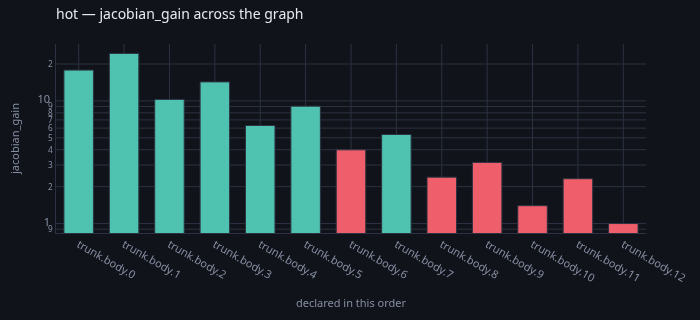

In [9]:
profile(store, run="hot", of="jacobian_gain")

And it raises nothing. Neither does `jacobian_spread`, which is what
dynamical isometry is actually a claim about — the *shape* of the spectrum and
not its size.

Both were measured against networks that genuinely cannot train, and both
**rank** without **separating**, which is not the same thing and only one of
them is a flag. The worst network that still trains reads a first-layer gain of
1.41 and the best one that does not reads 1.95: a factor of 1.4 is where the
sampling landed, not a bound. The spread inverts outright — 1.87 trains, 1.76
does not, so the network that failed had the *tighter* spectrum.

So they are recorded and drawn and no alarm was invented, which is what
`NARROWING` established as the thing to do. `health/tests/isometry.py` has the
table. There is a rule under all three:

> **What separates is a runaway. What ranks is a proxy.**

The forward scale is geometric: it stays put or leaves by decades, and there is
nothing in between to be wrong about. Anything that varies continuously with how
well a network turns out is a ranking — and a ranking belongs beside the
proxies, where a number only ever means something next to another candidate's.

## Scoring a candidate without training it

Which is exactly what the last piece is. `synflow` of one network is a number
with no meaning; it only means something next to another network's. So none of
these is a `Flag` — they are a **cheap objective** a search loop scores with
instead of training, and they take a graph the way `probe` does.

Three of the five never see a label at all.

In [10]:
shapes = [(depth, wide) for depth in (2, 4, 8) for wide in (16, 48)]
candidates = {f"d{depth}-w{wide}": built(depth=depth, wide=wide) for depth, wide in shapes}

for name, g in candidates.items():
    print(f"{name:8}", {one: round(what, 2) for one, what in proxies(g, ONE).items()})

d2-w16   {'synflow': 14.35, 'zen': 4.42, 'naswot': -532.64}
d2-w48   {'synflow': 15.39, 'zen': 4.54, 'naswot': 94.2}
d4-w16   {'synflow': 17.8, 'zen': 4.3, 'naswot': -220.37}
d4-w48   {'synflow': 20.01, 'zen': 4.48, 'naswot': 451.23}
d8-w16   {'synflow': 24.39, 'zen': 4.86, 'naswot': 228.42}
d8-w48   {'synflow': 28.79, 'zen': 4.48, 'naswot': 564.56}


Which leaves the only question worth asking of any of them, and it is not
*does it correlate with the score*:

> **Does it beat counting parameters?**

Size is free. So the baseline goes in the table beside every proxy, and the only
column that matters is the gap.

In [11]:
def spearman(a, b):
    """Rank correlation, the same thirty lines `study.importance` uses."""
    n = len(a)
    def ranked(values):
        order = sorted(range(n), key=lambda i: values[i])
        rank = [0.0] * n
        for at, which in enumerate(order):
            rank[which] = float(at)
        return rank
    ra, rb = ranked(a), ranked(b)
    ma, mb = sum(ra) / n, sum(rb) / n
    top = sum((x - ma) * (y - mb) for x, y in zip(ra, rb))
    left = math.sqrt(sum((x - ma) ** 2 for x in ra))
    right = math.sqrt(sum((y - mb) ** 2 for y in rb))
    return top / (left * right) if left and right else float("nan")


took = {name: proxies(g, ONE) for name, g in candidates.items()}
size = [sum(p.numel() for p in parameters(g)) for g in candidates.values()]
scored = []
for depth, wide in shapes:
    torch.manual_seed(0)
    # Higher is better, so the sign flips: every correlation is against **how
    # good the network turned out**.
    scored.append(-fit(built(depth=depth, wide=wide), steps=400))

base = spearman(size, scored)
print(f"{'parameters':>12}  rho vs score {base:6.2f}   (the baseline: size is free)")
for one in ("synflow", "zen", "naswot"):
    against = spearman([took[name][one] for name in candidates], scored)
    print(f"{one:>12}  rho vs score {against:6.2f}"
          f"   rho vs parameters {spearman([took[name][one] for name in candidates], size):6.2f}"
          f"   gap {against - base:+.2f}")

  parameters  rho vs score   0.83   (the baseline: size is free)
     synflow  rho vs score   0.94   rho vs parameters   0.71   gap +0.11
         zen  rho vs score   0.60   rho vs parameters   0.43   gap -0.23
      naswot  rho vs score   0.94   rho vs parameters   0.94   gap +0.11


Six candidates is not a benchmark. The measurement that is not a toy is
`health/tests/proxies.py` — twenty-four candidates, three seeds each — and the
interesting part is that **it does not agree with the table above**:

| | ρ vs score | ρ vs parameters | beats counting by |
|---|---|---|---|
| **parameters** | **0.59** | — | the baseline, and it costs nothing |
| `snip` | 0.61 | **-0.02** | **+0.02** |
| `naswot` | **0.69** | **0.97** | +0.10 |
| `zen` | 0.45 | -0.39 | -0.14 |
| `grasp` | -0.08 | 0.57 | -0.67 |
| `synflow` | **-0.16** | 0.42 | -0.75 |

`naswot` ranks best and is the least interesting: at 0.97 with parameter count
it **is** size, with noise on top. `snip` is the only one that beats counting
*and* is uncorrelated with it — two hundredths, but two hundredths of something
orthogonal to what size already says. And `synflow` comes out **worse than
nothing**, because on that family it reads *depth*, and depth is what hurts
there. The published 0.76 is on NAS-Bench-201, where depth and size move
together.

`synflow` came out **joint best** on the six candidates here and **worse than
nothing** on the twenty-four there. It is the same proxy and the same code; what
changed is the family. Here depth helps and `synflow` reads depth, so it looks
excellent; there depth hurts and it reads depth, so it looks terrible.

That is the whole argument for shipping all five and picking none. A default
would have been right on one of these two families and quietly wrong on the
other — and *quietly* is the problem, because a search that ranks by the wrong
number does not fail, it just returns the wrong architecture. Which one is worth
anything is a question with a cheap answer: measure it, on the family you are
actually searching, the way this file does.